<a href="https://colab.research.google.com/github/seungmei/QNS/blob/main/PTCDA%2BFe_simulation_huckel_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hückel Model: PTCDA + Fe

Fe atoms attach to PTCDA > dI/dV HOMO peak shifts left.

**How it works:**
1. Each atom gets a number on the diagonal (electronegativity, `h`)
2. Each bond gets a number off-diagonal (orbital overlap, `k`)
3. Diagonalize this matrix > orbital energies + shapes
4. Each energy > a peak in the dI/dV curve

---
### Parameters


| 파라미터 | 의미 | 값의 근거 |
|---|---|---|
| `h_O = 2.0` | O의 전기음성도. 대각 원소 `H[i,i] = h × β`에 들어감 | C=0 기준, O가 훨씬 전자를 강하게 끔 |
| `h_Fe = 0.8` | Fe 자체의 on-site energy | Fe d-orbital의 에너지 준위 |
| `k_CC = 1.0` | C-C 결합의 orbital overlap (기준값) | 모든 k가 이 값 대비 상대적 비율 |
| `k_CO = 0.8` | C-O 결합 강도 | C-C보다 약간 약한 π-overlap |
| `k_FeO = 0.5` | Fe-O coordination bond → **delocalization** 효과 제어 | 공유결합보다 약한 배위결합 |
| `coulomb_de = 0.15` | Fe 1개당 PTCDA 원자들이 느끼는 **electrostatic stabilization** | Fe⁺의 Coulomb 인력이 π-전자 에너지를 낮춤 |
| `beta = -1.0` | 에너지 단위 (eV). 음수: bonding orbital이 낮은 에너지를 갖는 convention | |
| `gamma = 0.18` | dI/dV peak의 반치폭 (thermal + instrumental broadening) | 실온 STM 전형값 |
| `e_scale`, `e_offset` | Hückel 에너지(β 단위) → 실험 voltage(V) 변환: `V = E × e_scale + e_offset` | 실험 peak 위치에 맞춰 조절 |

**HOMO shift:**
- `k_FeO` → **delocalization**: Fe d-orbital이 π-system과 섞여 MO가 확장됨
- `coulomb_de` → **electrostatic**: Fe⁺ 양전하가 PTCDA 전체 π-전자를 Coulomb 인력으로 안정화

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy, warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({'font.size': 10, 'axes.facecolor': '#0a0a0a',
                     'figure.facecolor': '#050505', 'axes.edgecolor': '#333'})

# ── Tunable parameters (adjust these to fit experimental data) ──
P = {
    'h_O':  2.0,   'h_Fe': 0.8,                     # on-site energy, electronegativity (on-site energy)
    'k_CC': 1.0,   'k_CO': 0.8,   'k_FeO': 0.5,    # hopping integral, bond strength (delocalization)
    'coulomb_de': 0.15,                               # electrostatic shift per Fe
    'beta': -1.0,                                     # energy unit (eV). bonding orbital < anti-bonding
    'gamma':  0.18,                                   # peak width < thermal broadening(STM resolution)
    'e_scale': 0.7, 'e_offset': -1.8,                # energy → voltage mapping
}

---
### Huckel engine — Matrix representation + Diagonalization

Hamiltonian: 전자가 어디에 있을 수 있고, 각 위치에서 에너지가 얼마이며, 이웃으로 뛰어넘기 얼마나 쉬운가. > "각 원자 위에서의 에너지 + 이웃으로의 이동 용이성"


`build_hamiltonian`: 원자 리스트와 결합 리스트를 받아서 Huckel 행렬을 만듦.
- **대각 원소, diagonal** `H[i,i] = h_X × β` — 원자 X가 전자를 얼마나 세게 잡는가 (Coulomb integral)
- **비대각 원소, off-diagonal** `H[i,j] = k_XY × β` — 결합된 두 원자 사이에서 전자가 얼마나 쉽게 오가는가 (resonance integral)
- 결합이 없는 원자 쌍은 `H[i,j] = 0` (Huckel 근사의 핵심 가정)
- **Electrostatic shift**: Fe가 존재하면 PTCDA 원자들의 대각 원소가 `coulomb_de × n_Fe × β`만큼 추가로 낮아짐 — Fe⁺의 양전하가 π-전자를 Coulomb 인력으로 안정화하는 효과

`solve`: 행렬을 만들고 > `np.linalg.eigh()`로 대각화 > eigenvalue(에너지)와 eigenvector(orbital 모양)를 에너지 순서대로 정렬해서 반환.

* **대각화** : eigenvalue = 각 MO의 에너지, eigenvector의 i번째 성분 = 그 MO에서 i번 원자가 얼마나 기여하는지(LCAO coeff.)

> **물리적 의미:** Hamiltonian 행렬은 "atomic orbital 기저에서 쓴 에너지 연산자"이고, 대각화하면 molecular orbital 기저로 변환되는 것. eigenvalue = MO 에너지, eigenvector의 i번째 성분 = i번 원자의 기여도 (LCAO coefficient).

In [2]:
# ── The entire Huckel engine is these two functions ──

def build_hamiltonian(atoms, bonds):
    """Atom types + bonds → Hückel matrix."""
    n = len(atoms) # number of atoms
    H = np.zeros((n, n))

    # Diagonal: how strongly each atom holds its electron
    h = {'C': 0, 'O': P['h_O'], 'Fe': P['h_Fe']} # on-site energy which is atomic orbital energy
    for i in range(n): #H_ii = alpha_i
        H[i, i] = h.get(atoms[i], 0) * P['beta']

    """ Electrostatic shift: Fe⁺ cation stabilizes ALL π-electrons on PTCDA
     (This lowers every non-Fe diagonal element proportional to # of Fe atoms)"""
    n_fe = atoms.count('Fe')
    if n_fe > 0: # if there's more than one Fe atoms, electrostatic effect.
        for i in range(n):
            if atoms[i] != 'Fe':
                H[i, i] += P['coulomb_de'] * n_fe * P['beta']

    # Off-diagonal: how well electrons hop across each bond
    # Using frozenset so atom name order doesn't matter
    # frozenset: 수정불가능한 집합
    # C-C: strong pi bond, C-O:weaker pi bond, Fe-O
    k = {frozenset(['C','C']): P['k_CC'],  frozenset(['C','O']):  P['k_CO'],
         frozenset(['C','Fe']): P['k_FeO'], frozenset(['Fe','O']): P['k_FeO']}
    for i, j in bonds:
        pair = frozenset([atoms[i], atoms[j]])
        H[i, j] = H[j, i] = k.get(pair, 0.5) * P['beta'] #H_ij = H_ji

    return H


def solve(atoms, bonds):
    """Build matrix → diagonalize → sorted energies and orbitals."""
    H = build_hamiltonian(atoms, bonds)
    energies, orbitals = np.linalg.eigh(H)
    order = np.argsort(energies)
    return H, energies[order], orbitals[:, order]

---
### Spectrum — eigenvalue > dI/dV, LDOS

dI/dV: voltage V에서 터널링할 수 있는 상태가 얼마나 많은지. > density of state(DOS)에 비례.

**`lorentzian`**: 하나의 MO 에너지가 dI/dV에서 하나의 peak으로 나타남. delta function 대신 유한한 폭(`gamma`)을 가진 Lorentzian을 사용 — 실험에서 thermal broadening과 기기 resolution이 peak을 퍼뜨리는 효과.

**`to_voltage`**: Huckel eigenvalue(β 단위) > 실험 voltage(V) 매핑. `V = E × e_scale + e_offset`. 순수 phenomenological한 변환.

**`calc_dIdV`**: 모든 MO 에너지에 Lorentzian을 놓고 합산 = total DOS. STM tip이 분자 전체를 균일하게 평균낼 때, dI/dV ∝ total DOS가 성립. (Σᵢ|cᵢₙ|² = 1 이므로 LDOS 합 = total DOS)

**`calc_ldos`**: 각 원자별로 기여를 분해한 것. i번 원자의 LDOS = Σₙ |cᵢₙ|² × L(V − Eₙ). 여기서 cᵢₙ은 n번째 MO에서 i번 원자의 LCAO 계수. 이것이 STM의 dI/dV mapping이 측정하는 양 — 특정 bias에서 각 원자 위치의 터널링 확률.

In [3]:
def lorentzian(V, center):
    """One peak centered at 'center'.
    sepctral peak.
    one molecular orbital means one STS peak"""
    return P['gamma'] / (np.pi * ((V - center)**2 + P['gamma']**2))


def to_voltage(energy):
    """Convert Hückel energy → experimental voltage."""
    return energy * P['e_scale'] + P['e_offset']

# En at each MO energy state
# total STM spectrum
def calc_dIdV(energies, V):
    """dI/dV = sum of peaks, one per orbital."""
    return sum(lorentzian(V, to_voltage(E)) for E in energies)

# Local Density Of States
# 각 atom이 STM signal에 얼마나 기여하는지
def calc_ldos(energies, orbitals, V):
    """LDOS at each atom: how much each atom contributes to the signal at each voltage.
    ρᵢ(V) = Σₙ |cᵢₙ|² × L(V − Eₙ)
    """
    n_atoms = orbitals.shape[0]
    ldos = np.zeros((n_atoms, len(V)))
    for n in range(len(energies)):
        peak = lorentzian(V, to_voltage(energies[n]))          # shape of this orbital's peak
        weight = orbitals[:, n]**2                              # how much each atom participates
        ldos += weight[:, None] * peak[None, :]                # outer product
    return ldos

---
### PLOT

In [4]:
def draw_molecule(ax, xy, bonds, atoms, values=None, mode='mo'):
    """Draw molecule with optional orbital/LDOS coloring.
    mode='mo':   values = orbital coefficients (blue +, red −)
    mode='ldos': values = LDOS intensities (bright = high)
    """
    ax.set_aspect('equal'); ax.set_facecolor('#0a0a0a'); ax.axis('off')
    atom_color = {'C': '#666', 'O': '#dc2626', 'Fe': '#fbbf24'}

    for i, j in bonds:
        ax.plot([xy[i][0], xy[j][0]], [xy[i][1], xy[j][1]], '#333', lw=0.8)

    if values is not None:
        mx = max(abs(values)) + 1e-10
        for i in range(len(atoms)):
            if mode == 'mo':
                r = abs(values[i]) / mx * 0.4 + 0.03
                ax.add_patch(plt.Circle(xy[i], r,
                    color='#3b82f6' if values[i] >= 0 else '#ef4444', alpha=0.45))
            elif mode == 'ldos':
                from matplotlib.cm import inferno
                r = values[i] / mx * 0.4 + 0.03
                ax.add_patch(plt.Circle(xy[i], r, color=inferno(values[i]/mx), alpha=0.7))

    for i in range(len(atoms)):
        ax.plot(*xy[i], 'o', color=atom_color.get(atoms[i], '#888'),
                ms={'C':2,'O':3,'Fe':5}.get(atoms[i], 3))
        if atoms[i] == 'Fe':
            ax.plot(*xy[i], 's', mfc='none', mec='#fbbf24', mew=1.5, ms=10)


def auto_layout(atoms, bonds):
    """Generate 2D coordinates. (Only for drawing — eigenvalues don't depend on positions.)"""
    n = len(atoms); np.random.seed(42)
    pos = np.random.randn(n, 2) * 2
    for _ in range(800):
        f = np.zeros_like(pos); dt = 0.02
        for i in range(n):
            for j in range(i+1, n):
                d = pos[i]-pos[j]; r = max(np.linalg.norm(d), 0.01)
                f[i] += 1.5*d/r**3; f[j] -= 1.5*d/r**3
        for i,j in bonds:
            d = pos[j]-pos[i]; r = max(np.linalg.norm(d), 0.01)
            pull = 2*(r-1)*d/r; f[i] += pull; f[j] -= pull
        pos += dt * f
    return pos - pos.mean(0)

---
## 1. Benzene으로 모델 검증

- 6개 C, 각각 1 π-electron → 총 6 π-electrons
- 알려진 해석해: eigenvalue = α+2β, α+β(×2), α−β(×2), α−2β (α=0 기준)
- HOMO-LUMO gap = 2β

이 셀에서 계산한 eigenvalue가 위 결과와 일치하면, `build_hamiltonian` + `solve`가 올바르게 작동하는 것.

**HOMO index 계산:** `ne // 2 - 1`. 6 electrons → 3개 MO에 각각 ↑↓ 채움 → HOMO = 3번째(index 2).

**Plot:** 왼쪽 = dI/dV (각 eigenvalue에 Lorentzian peak), 오른쪽 = HOMO orbital (원 크기 = 각 C 원자의 LCAO 계수).

Hamiltonian:
[[-0. -1.  0.  0.  0. -1.]
 [-1. -0. -1.  0.  0.  0.]
 [ 0. -1. -0. -1.  0.  0.]
 [ 0.  0. -1. -0. -1.  0.]
 [ 0.  0.  0. -1. -0. -1.]
 [-1.  0.  0.  0. -1. -0.]]

Energies / β: [ 2.  1.  1. -1. -1. -2.]
Expected:      [2, 1, 1, -1, -1, -2]  ✓
HOMO-LUMO gap: 2.0β (expect 2.0β)


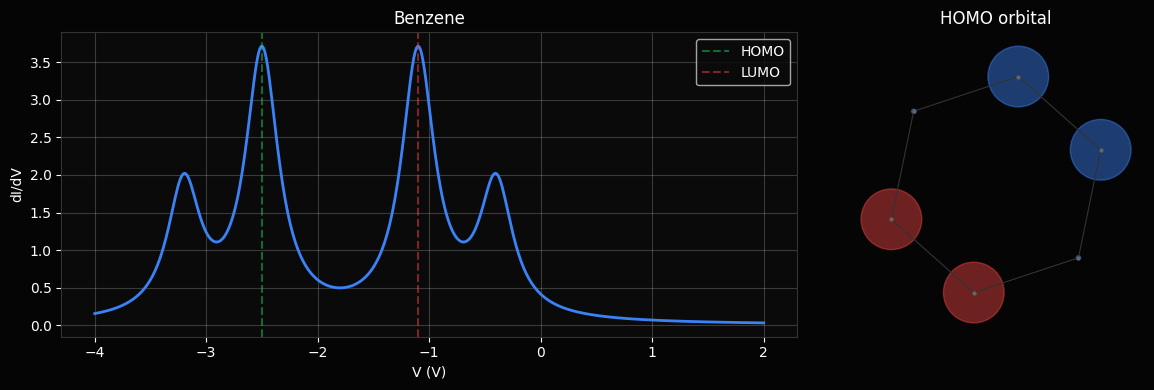

In [5]:
benz_atoms = ['C'] * 6
benz_bonds = [(i, (i+1) % 6) for i in range(6)]
benz_ne = 6  # 6 carbons × 1 electron each

H, energies, orbitals = solve(benz_atoms, benz_bonds)
hi = benz_ne // 2 - 1  # HOMO index

print("Hamiltonian:")
print(np.array2string(H, precision=2))
print(f"\nEnergies / β: {energies / P['beta']}")
print(f"Expected:      [2, 1, 1, -1, -1, -2]  ✓")
print(f"HOMO-LUMO gap: {energies[hi+1] - energies[hi]:.1f}β (expect 2.0β)")

# ── Plot ──
V = np.linspace(-4, 2, 500)
xy = auto_layout(benz_atoms, benz_bonds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
ax1.plot(V, calc_dIdV(energies, V), '#3b82f6', lw=2)
ax1.axvline(to_voltage(energies[hi]), color='#22c55e', ls='--', alpha=0.5, label='HOMO')
ax1.axvline(to_voltage(energies[hi+1]), color='#ef4444', ls='--', alpha=0.5, label='LUMO')
ax1.set(xlabel='V (V)', ylabel='dI/dV', title='Benzene'); ax1.legend(); ax1.grid(alpha=0.2)

draw_molecule(ax2, xy, benz_bonds, benz_atoms, orbitals[:, hi], 'mo')
ax2.set_title('HOMO orbital')
plt.tight_layout(); plt.show()

---
## 2. PTCDA + Fe

### 분자 구조 정의

**Perylene core (atom 0-19, 20개 C):** 5개 hexagonal ring이 peri-fusion으로 연결됨. 각 Ring은 이전 Ring과 edge를 공유.
```
Ring A: 0-1-2-3-4-5       (6 atoms)
Ring B: 5-0-6-7-8-9       (shares edge 0-5, adds 4 atoms)
Ring C: 7-8-9-10-11-12    (shares 2 edges with B, adds 3)  ← 중심 ring
Ring D: 10-11-12-13-14-15 (shares 2 edges with C, adds 3)
Ring E: 14-15-16-17-18-19 (shares edge 14-15, adds 4)
```

**Anhydride groups (atom 20-29):**
- atom 20-23: exocyclic carbonyl C — perylene ring 바깥에 붙은 C=O의 탄소
- atom 24-27: carbonyl O (=O) — 이중결합 산소, **1 π-electron** 기여 (pyridine N과 유사)
- atom 28-29: bridge O (-O-) — 두 carbonyl C를 잇는 산소, **2 π-electrons** 기여 (lone pair가 π-system 참여, pyrrole N과 유사)

**π-electron 합산:** 24C×1 + 4 carbonyl O×1 + 2 bridge O×2 = **32**

In [13]:
# ── Perylene core: 5 peri-fused hexagonal rings, 20 C ──
#   Ring A: 0-1-2-3-4-5       Ring B: 5-0-6-7-8-9
#   Ring C: 7-8-9-10-11-12    Ring D: 10-11-12-13-14-15
#   Ring E: 14-15-16-17-18-19

perylene_bonds = [
    (0,1),(1,2),(2,3),(3,4),(4,5),(5,0),     # A
    (0,6),(6,7),(7,8),(8,9),(9,5),            # B
    (9,10),(10,11),(11,12),(12,7),            # C (center)
    (12,13),(13,14),(14,15),(15,10),          # D
    (15,16),(16,17),(17,18),(18,19),(19,14),  # E
]

# ── Anhydride groups ──
anhydride_bonds = [
    (1,20),(2,21),             # exocyclic C at top
    (18,22),(19,23),           # exocyclic C at bottom
    (20,24),(21,25),           # top carbonyl O (=O, 1 e⁻ each)
    (22,26),(23,27),           # bottom carbonyl O
    (20,28),(21,28),           # top bridge O (-O-, 2 e⁻)
    (22,29),(23,29),           # bottom bridge O
]

ptcda_atoms = ['C']*24 + ['O']*6            # 20 ring C + 4 exocyclic C + 4 carbonyl O + 2 bridge O
ptcda_bonds = perylene_bonds + anhydride_bonds
ptcda_ne = 32                                # 24×1 + 4×1 + 2×2
ptcda_xy = auto_layout(ptcda_atoms, ptcda_bonds)

print(f"PTCDA: {len(ptcda_atoms)} atoms, {ptcda_ne} π-electrons")

PTCDA: 30 atoms, 32 π-electrons


### Fe 부착 + 전체 풀이

**`add_fe(n_fe)`**: PTCDA의 carbonyl oxygen(atom 24-27)에 Fe를 1-4개 부착.
- Fe는 Lewis acid — d-electron은 localized되어 π-system에 참여하지 않음 > **0 π-electron 기여**
- Fe가 MO에 미치는 영향은 두 가지 **독립적** 메커니즘:
  1. **Delocalization** (`k_FeO`, 비대각 원소): Fe d-orbital이 O p-orbital과 섞이면서 π-system이 확장됨
  2. **Electrostatic stabilization** (`coulomb_de`, 대각 원소 shift): Fe⁺ 양전하가 PTCDA의 **모든** π-전자를 Coulomb 인력으로 끌어당겨 에너지를 낮춤
- 두 효과 모두 occupied MO 에너지를 낮추므로, dI/dV HOMO peak이 더 음의 bias로 이동
- Electrostatic 효과는 Fe 개수에 **비례**하므로, Fe가 많을수록 shift가 더 커짐 (delocalization만으로는 2Fe 이후 shift가 포화되는 경향이 있었음)

`results` 리스트에 0Fe~4Fe 각각의 Hamiltonian, eigenvalue, eigenvector, HOMO 위치를 저장. 이후 모든 plot이 이 리스트를 참조.

In [14]:
def add_fe(n_fe):
    """Attach 1-4 Fe atoms to PTCDA's carbonyl oxygens."""
    atoms = list(ptcda_atoms)
    bonds = list(ptcda_bonds)
    xy = list(ptcda_xy)
    carbonyl_O = [24, 25, 26, 27]

    for i in range(min(n_fe, 4)):
        fe_idx = len(atoms)
        atoms.append('Fe')
        bonds.append((carbonyl_O[i], fe_idx))
        # Place Fe near its oxygen (for drawing only)
        ox, oy = xy[carbonyl_O[i]]
        xy.append((ox + 0.8*(1 if i%2 else -1), oy + 0.8*(1 if i<2 else -1)))

    return atoms, bonds, np.array(xy), ptcda_ne  # Fe adds 0 electrons


# Solve
results = []
for n_fe in range(5):
    if n_fe == 0:
        atoms, bonds, xy, ne = ptcda_atoms, ptcda_bonds, ptcda_xy, ptcda_ne
    else:
        atoms, bonds, xy, ne = add_fe(n_fe)

    H, energies, orbitals = solve(atoms, bonds)
    hi = ne // 2 - 1
    homo_V = to_voltage(energies[hi])

    results.append({
        'atoms': atoms, 'bonds': bonds, 'xy': xy, 'ne': ne,
        'H': H, 'energies': energies, 'orbitals': orbitals,
        'hi': hi, 'homo_V': homo_V,
    })
    shift = homo_V - results[0]['homo_V']
    print(f"{n_fe} Fe: HOMO = {homo_V:.4f} V  (shift {shift:+.4f} V)")

COLORS = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444', '#a855f7']
LABELS = ['PTCDA', '1 Fe', '2 Fe', '3 Fe', '4 Fe']

0 Fe: HOMO = -2.1492 V  (shift +0.0000 V)
1 Fe: HOMO = -2.3059 V  (shift -0.1567 V)
2 Fe: HOMO = -2.3796 V  (shift -0.2304 V)
3 Fe: HOMO = -2.4738 V  (shift -0.3246 V)
4 Fe: HOMO = -2.5800 V  (shift -0.4308 V)


---
### Hamiltonian 행렬 시각화 (AO → MO)

Huckel 행렬을 heatmap으로 시각화.

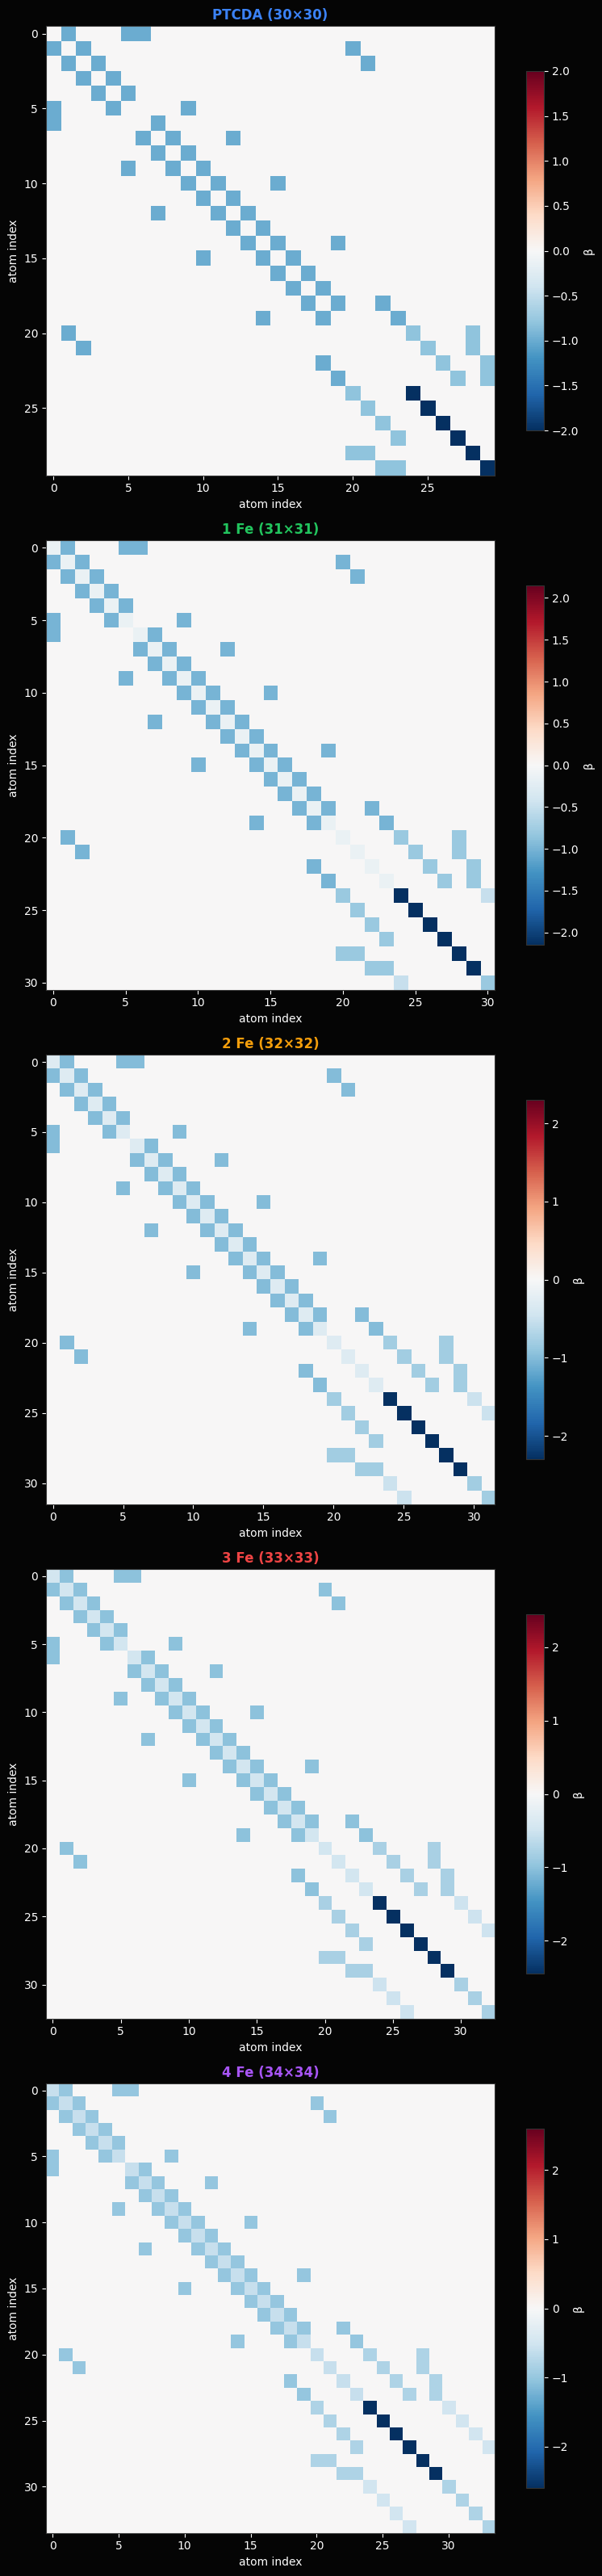

In [16]:
fig, axes = plt.subplots(5, 1, figsize=(8, 32))
for i, ax in enumerate(axes):
    H = results[i]['H']; vm = max(abs(H.min()), abs(H.max()))
    im = ax.imshow(H, cmap='RdBu_r', vmin=-vm, vmax=vm)
    ax.set_title(f'{LABELS[i]} ({H.shape[0]}×{H.shape[0]})', fontweight='bold', color=COLORS[i])
    ax.set_xlabel('atom index'); ax.set_ylabel('atom index')
    plt.colorbar(im, ax=ax, shrink=0.8, label='β')
plt.tight_layout(); plt.show()

---
### V vs dI/dV


**why does the peak shifted to left? 왜 왼쪽으로 이동하는가:**
- Fe 하나 추가 시, 행렬에서 보면 H[Fe, 0] = k_Fe0 * beta = -0.5 라는 off-diagonal element 추가. > 전자가 O, Fe로 넘나들 수 있음. Fe d-orbital까지 : delocalization > 전자가 갇힌 공간이 넓어지면 에너지가 낮아짐. ~1/L^2

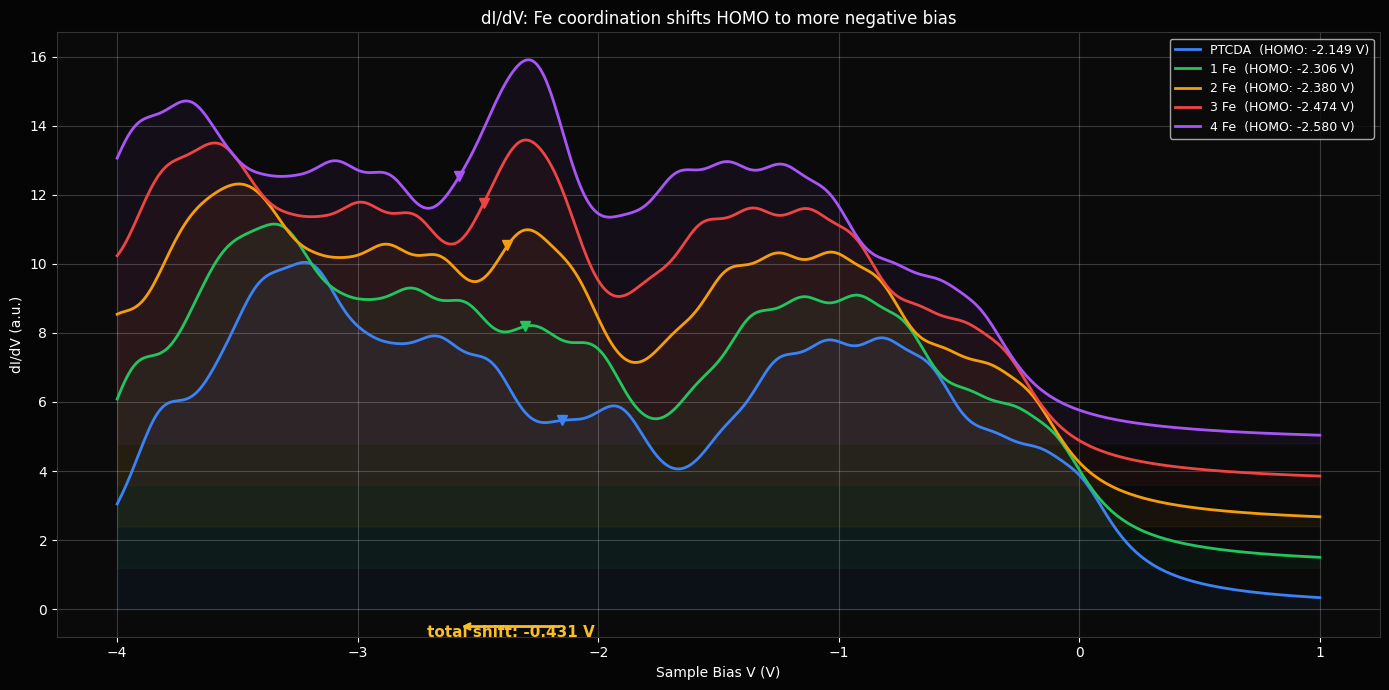

In [17]:
V = np.linspace(-4, 1, 500)
fig, ax = plt.subplots(figsize=(14, 7))

for i, r in enumerate(results):
    dIdV = calc_dIdV(r['energies'], V)
    offset = i * 1.2
    ax.plot(V, dIdV + offset, color=COLORS[i], lw=2,
            label=f"{LABELS[i]}  (HOMO: {r['homo_V']:.3f} V)")
    ax.fill_between(V, offset, dIdV + offset, color=COLORS[i], alpha=0.06)
    # Mark HOMO peak
    ix = np.argmin(np.abs(V - r['homo_V']))
    ax.plot(r['homo_V'], dIdV[ix] + offset, 'v', color=COLORS[i], ms=7)

# Shift arrow
ax.annotate('', xy=(results[-1]['homo_V'], -0.5),
            xytext=(results[0]['homo_V'], -0.5),
            arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=2))
ax.text(np.mean([results[0]['homo_V'], results[-1]['homo_V']]), -0.8,
        f"total shift: {results[-1]['homo_V'] - results[0]['homo_V']:.3f} V",
        ha='center', color='#fbbf24', fontsize=11, fontweight='bold')

ax.set(xlabel='Sample Bias V (V)', ylabel='dI/dV (a.u.)',
       title='dI/dV: Fe coordination shifts HOMO to more negative bias')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

---
### changes in HOMO orbital as a molecule gets more Fe atoms

Fe 개수에 따라 HOMO orbital의 모양이 어떻게 바뀌는지.

HOMO eigenvector c_i

- 파란 원= c_i > 0 constructive
- 빨간 원 = c_i < 0 destructive > node
- 원 크기 = |c_i| (그 원자가 이 orbital에 얼마나 기여하는지)

Fe가 추가될수록 orbital이 Fe 쪽으로 일부 확장(delocalization) or 기존 원자들의 계수가 재분배.

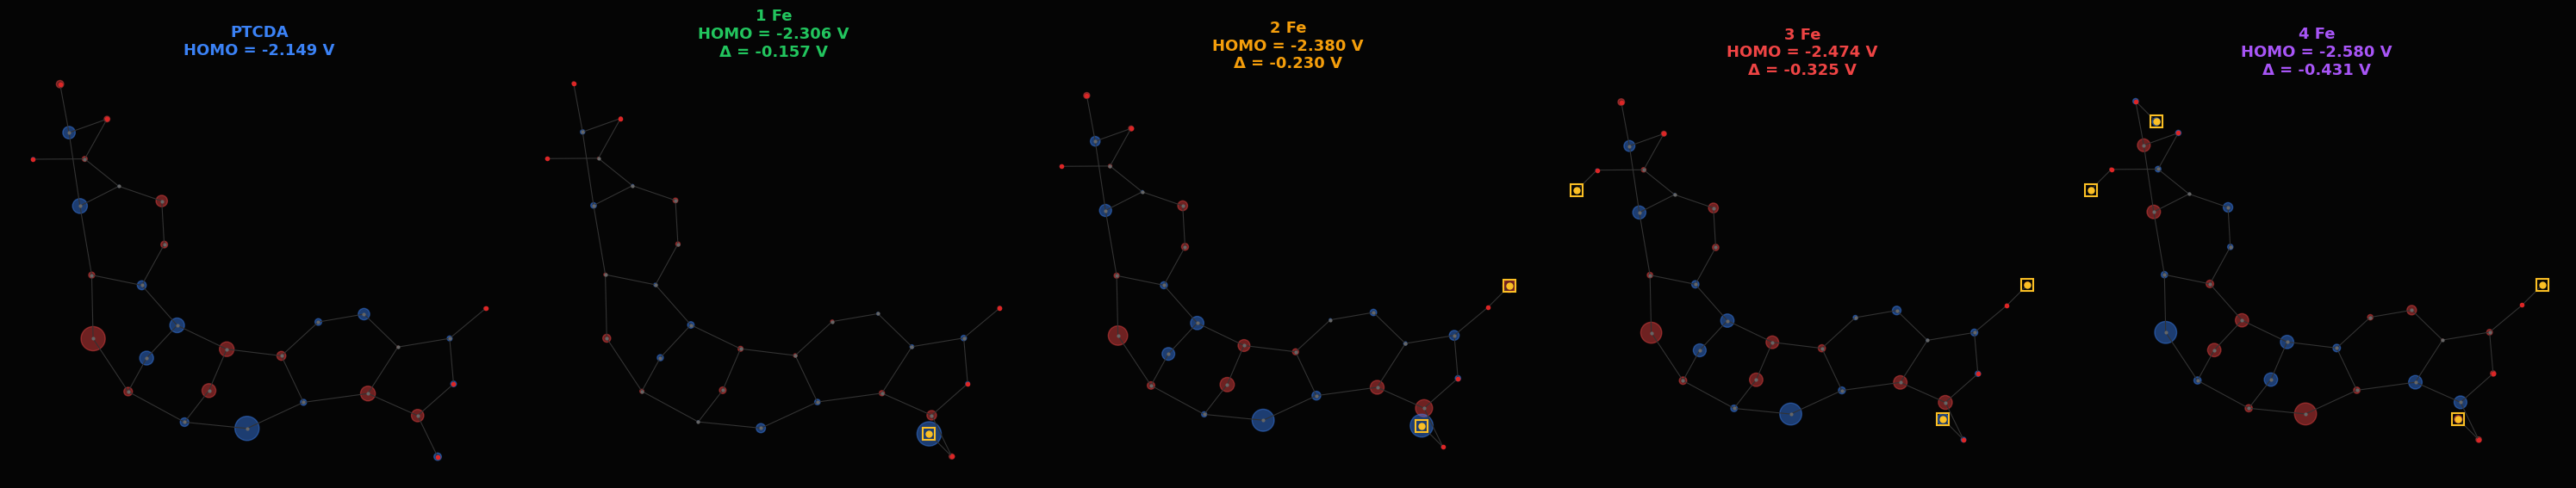

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(30, 8))
for i, r in enumerate(results):
    ax = axes[i]
    draw_molecule(ax, r['xy'], r['bonds'], r['atoms'],
                  r['orbitals'][:, r['hi']], mode='mo')
    shift = r['homo_V'] - results[0]['homo_V']
    title = f"{LABELS[i]}\nHOMO = {r['homo_V']:.3f} V"
    if i > 0: title += f"\nΔ = {shift:+.3f} V"
    ax.set_title(title, fontsize=13, fontweight='bold', color=COLORS[i])
plt.tight_layout(); plt.show()

---
### LDOS — 원자 종류별 기여 (Partial DOS)

$\rho_i(V) = \sum_n |c_{i,n}|^2 \cdot L(V - E_n)$

`calc_ldos()`로 모든 원자의 LDOS를 계산한 뒤, 원자 종류(C, O, Fe)별로 합산하면 **partial DOS (PDOS)**.

- grey = contribution of C atoms
- red = contribution of O atoms   
- yello = contribution of Fe atoms
- white dotted (= total DOS = dI/dV)

Fe 개수가 늘수록 Fe PDOS가 생기고, 동시에 C/O의 PDOS 모양도 바뀜 > Fe가 기존 π-system의 전자구조를 재배치하고 있음을 보여줌.

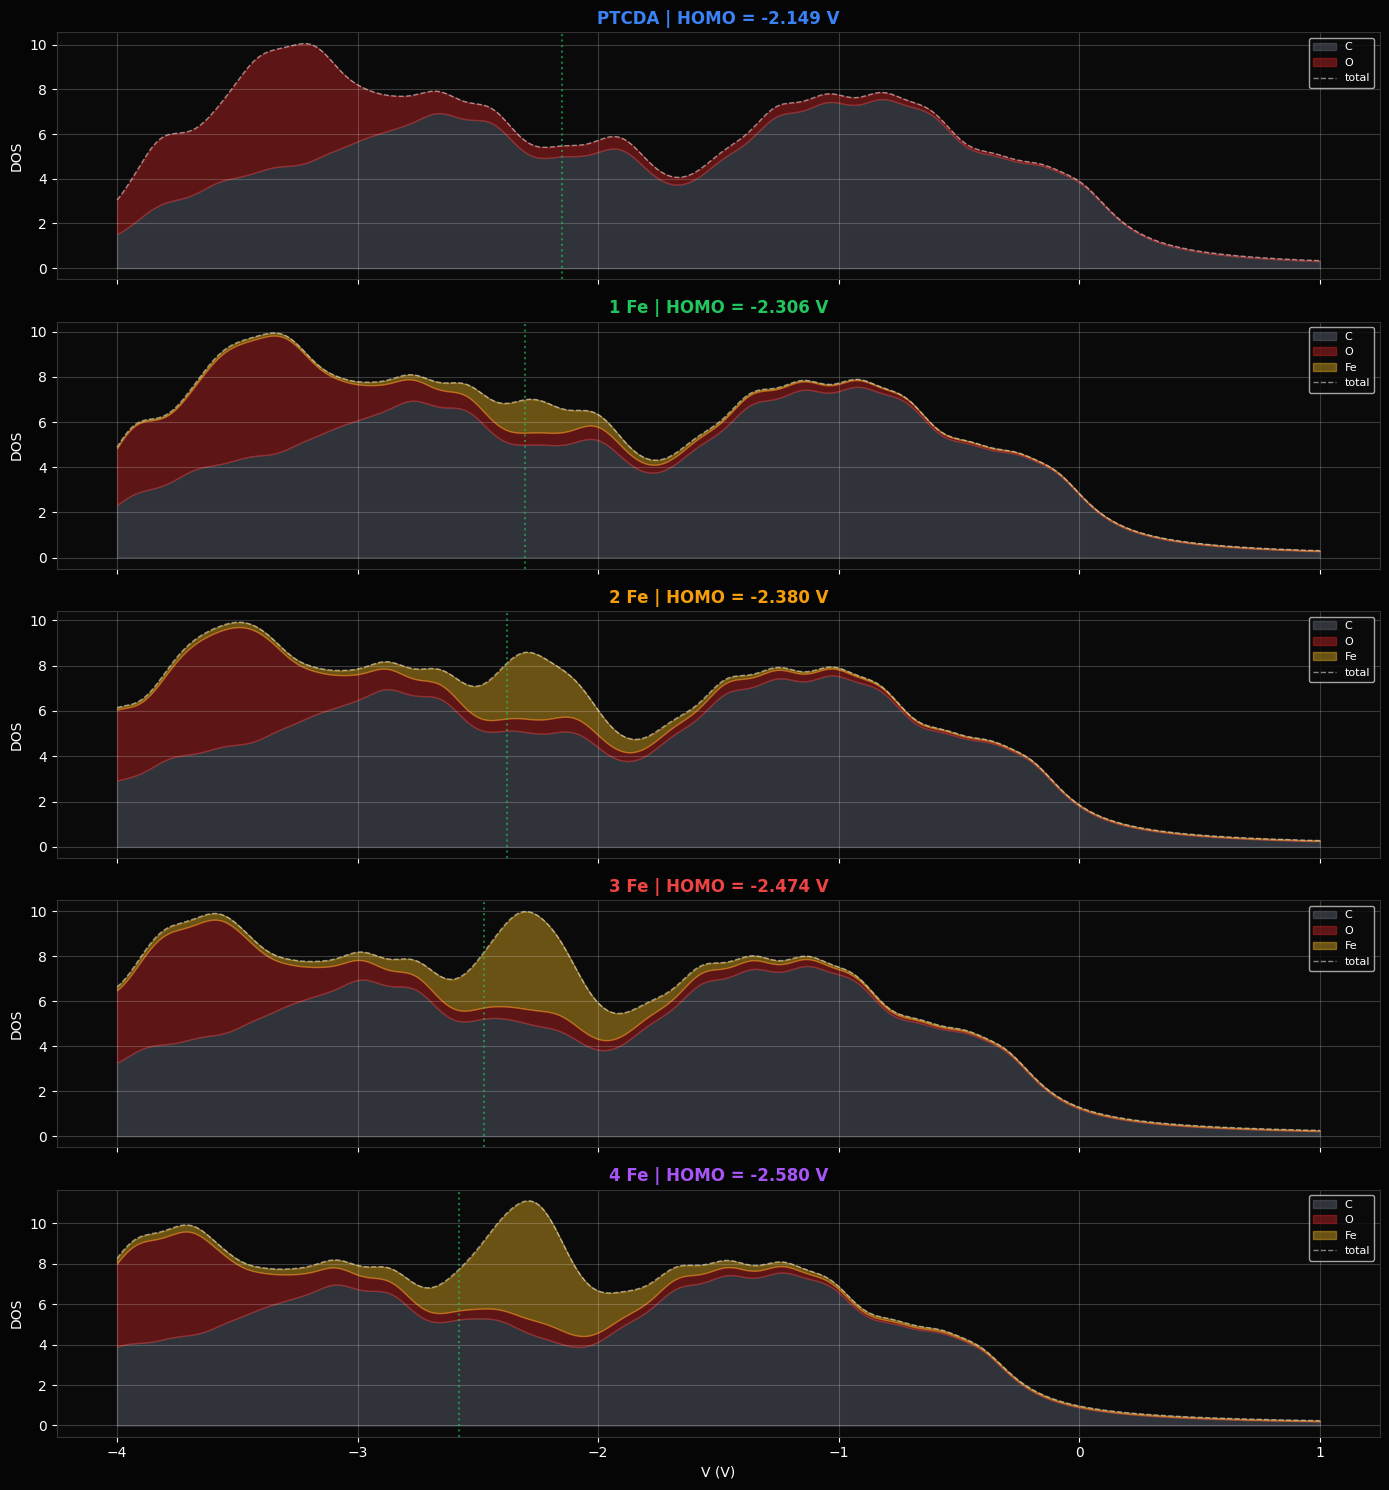

In [19]:
V = np.linspace(-4, 1, 400)
pdos_color = {'C': '#6b7280', 'O': '#dc2626', 'Fe': '#fbbf24'}

fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
for i, r in enumerate(results):
    ax = axes[i]
    ldos = calc_ldos(r['energies'], r['orbitals'], V)

    # Sum LDOS by atom type → partial DOS
    pdos = {}
    for j, t in enumerate(r['atoms']):
        if t not in pdos: pdos[t] = np.zeros_like(V)
        pdos[t] += ldos[j]

    # Stacked area plot
    bottom = np.zeros_like(V)
    for t in ['C', 'O', 'Fe']:
        if t in pdos:
            ax.fill_between(V, bottom, bottom + pdos[t],
                           color=pdos_color[t], alpha=0.4, label=t)
            bottom += pdos[t]
    ax.plot(V, ldos.sum(axis=0), 'w--', lw=1, alpha=0.5, label='total')
    ax.axvline(r['homo_V'], color='#22c55e', ls=':', alpha=0.6)
    ax.set_ylabel('DOS')
    ax.set_title(f"{LABELS[i]} | HOMO = {r['homo_V']:.3f} V",
                color=COLORS[i], fontweight='bold')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.2)

axes[-1].set_xlabel('V (V)')
plt.tight_layout(); plt.show()

---
### spatial LDOS — dI/dV map in HOMO energy(voltage)

HOMO 에너지(voltage)에서 각 원자의 LDOS를 계산해서 분자 위에 그린 것. 실험에서 **constant-height dI/dV mapping**으로 측정.

`draw_molecule(mode='ldos')`를 사용 — brighter > higher chance of quantum tunneling

각 원자 위의 LDOS는 `Σₙ |cᵢₙ|² × L(V_HOMO − Eₙ)`으로 계산. HOMO 에너지에서는 HOMO orbital이 지배적이므로, 이 map은 사실상 |c_i,HOMO|²의 공간 분포에 가까움.

ρi​(VHOMO​)=n∑​∣ci,n​∣2⋅L(VHOMO​−En​)

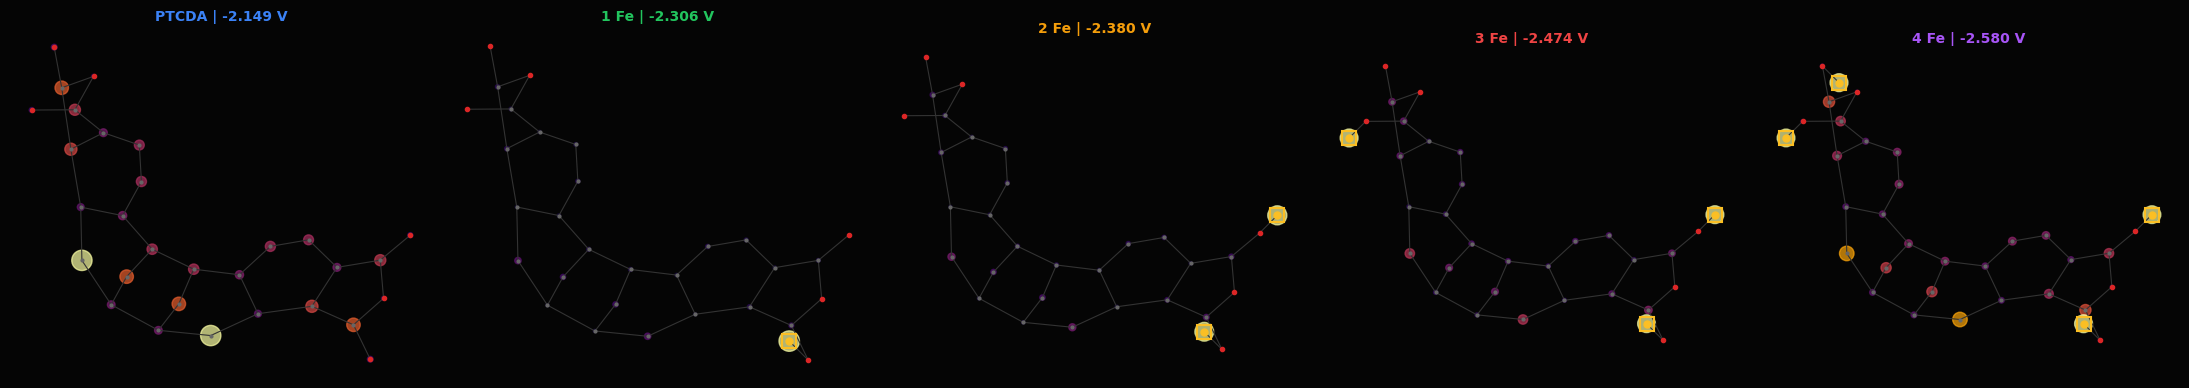

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, r in enumerate(results):
    ax = axes[i]
    # LDOS at the HOMO voltage for each atom
    ldos_map = sum(
        r['orbitals'][:, n]**2 * lorentzian(r['homo_V'], to_voltage(r['energies'][n]))
        for n in range(len(r['energies']))
    )
    draw_molecule(ax, r['xy'], r['bonds'], r['atoms'], ldos_map, mode='ldos')
    title = f"{LABELS[i]} | {r['homo_V']:.3f} V"
    ax.set_title(title, fontsize=10, fontweight='bold', color=COLORS[i])
plt.tight_layout(); plt.show()